# Rendement et volatilité — les deux nombres que tout le monde utilise mal


**Vidéos qui s'appuieront sur celle-ci plus tard :** quasiment toutes (rendement et volatilité sont
réutilisés dans chaque vidéo du parcours).

---

**Sources principales :**
- Support de cours interne — *Volatilité*, *Mouvement Brownien*
- J. Hull, *Options, Futures and Other Derivatives*, 8e éd., §14.4 (Volatility) et Business
  Snapshot 14.1 (*Mutual Fund Returns Can Be Misleading*)

**Note de transparence :** les données utilisées dans ce notebook sont **simulées** (mouvement
brownien géométrique), pas une vraie série de marché.


## 1. Question

**Problème central :**

> Deux séries de rendements annuels peuvent avoir exactement la même moyenne arithmétique, et
> pourtant faire gagner des montants très différents à quelqu'un qui reste investi plusieurs
> années. Comment est-ce possible — et qu'est-ce que ça a à voir avec la volatilité ?

**Pourquoi ça compte :** "rendement moyen" est probablement le chiffre le plus cité et le plus mal
compris de toute la finance. Un gérant, un indice, une stratégie peuvent afficher un rendement
moyen impressionnant tout en ayant réellement fait gagner beaucoup moins que ce chiffre ne le
suggère — et l'écart n'est pas un hasard, il est directement lié à la volatilité.


## 2. Intuition

Prenez un exemple simple : une action monte de 20%, puis redescend de 20%. La moyenne de ces deux
rendements est 0%. Vous vous attendez à retrouver votre capital de départ.

Sauf que ce n'est pas ce qui se passe. 100€ qui montent de 20% deviennent 120€. Puis 120€ qui
baissent de 20% deviennent 96€. Vous avez perdu 4€, alors que la moyenne de vos deux rendements
est exactement zéro.

Ce n'est pas un piège de calcul, c'est structurel : les rendements se **multiplient** dans le temps
(un facteur de croissance après l'autre), ils ne s'**additionnent** pas. Et cette différence entre
"moyenne des rendements" et "rendement réellement obtenu" grandit avec la volatilité : plus les
mouvements sont violents dans un sens puis dans l'autre, plus l'écart se creuse. C'est cette
mécanique qu'on va formaliser, puis vérifier numériquement.


## 3. Hypothèses

1. **Rendements journaliers indépendants et identiquement distribués (i.i.d.)** dans la partie
   simulation — pas d'autocorrélation, pas de "mémoire" du marché.
2. **Volatilité constante** sur toute la période simulée (pas de volatilité stochastique ici).
3. **Pas de dividendes ni de frais de transaction** dans les exemples utilisés.
4. **Les rendements log sont approximativement normaux**, ce qui entraîne des prix approximativement
   log-normaux (mouvement brownien géométrique).


## 4. Notation

| Symbole | Signification |
|---|---|
| $S_t$ | prix à l'instant $t$ |
| $r_t = S_t/S_{t-1} - 1$ | rendement relatif (simple) |
| $R_t = \ln(S_t/S_{t-1})$ | rendement logarithmique |
| $\mu$ | rendement moyen (dérive) |
| $\sigma$ | volatilité (écart-type du rendement) |


## 5. Mathématiques

**5.1 — Deux façons de mesurer un rendement.** Le rendement relatif et le rendement logarithmique
sont liés par :

$$R_t = \ln(1+r_t) \approx r_t \quad \text{pour } r_t \text{ petit}$$

Cette approximation (développement limité à l'ordre 1) est excellente pour de petits mouvements
journaliers, mais se dégrade pour de grands mouvements — on va le vérifier numériquement.

**5.2 — Moyenne, variance, écart-type.**

$$\bar{r} = \frac{1}{n}\sum_{i=1}^n r_i \qquad s^2 = \frac{1}{n-1}\sum_{i=1}^n (r_i-\bar{r})^2 \qquad \sigma = \sqrt{s^2}$$

**5.3 — Annualisation.** Avec 252 jours de bourse par an :

$$\sigma_{annuel} = \sqrt{252}\times\sigma_{journalier}$$

**5.4 — Le cœur du sujet : pourquoi la moyenne arithmétique ment.** Un capital investi $n$ années
avec des rendements $r_1,...,r_n$ devient :

$$C_n = C_0 \times \prod_{i=1}^n (1+r_i)$$

Le **rendement réellement obtenu par an** (rendement composé, ou moyenne géométrique) est :

$$g = \left(\frac{C_n}{C_0}\right)^{1/n} - 1$$



**D'où sort cette approximation ? Trois lignes d'algèbre, pas plus.**

On part de la définition du capital composé, et on prend le logarithme des deux côtés :

$$(1+g)^n = \prod_{i=1}^n (1+r_i) \quad\Longrightarrow\quad n\ln(1+g) = \sum_{i=1}^n \ln(1+r_i)$$

On applique le développement de Taylor **au second ordre** (pas celui du premier ordre vu en
section 6 — celui-là ne suffit pas ici, on le vérifie juste après) à chaque terme :
$\ln(1+x) \approx x - x^2/2$. En l'appliquant à $g$ (qui reste petit) et à chaque $r_i$ :

$$n\,g \;\approx\; \sum_{i=1}^n \left(r_i - \frac{r_i^2}{2}\right) = n\bar{r} - \frac{n}{2}\,\overline{r^2}$$

$$g \;\approx\; \bar{r} - \frac{\overline{r^2}}{2}$$

Dernière étape, une approximation supplémentaire à noter explicitement : $\overline{r^2} =
\text{Var}(r) + \bar{r}^2$, et quand $\bar{r}$ est petit devant $\text{Var}(r)$, on peut négliger
$\bar{r}^2$ et remplacer $\overline{r^2}$ par $\text{Var}(r)$ seul — ce qui donne la formule finale :



qui n'est **pas** égal à la moyenne arithmétique $\bar{r}$ dès que les rendements varient.

$$g \approx \bar{r} - \frac{\text{Var}(r)}{2}$$

**C'est l'équation clé de toute la vidéo** : l'écart entre ce qu'on croit gagner (la moyenne) et ce
qu'on gagne réellement (le composé) est directement proportionnel à la **variance** des
rendements — donc au carré de la volatilité. Plus c'est volatil, plus l'écart se creuse, même à
moyenne arithmétique égale.


In [1]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
rng = np.random.default_rng(42)


## 6. Implémentation



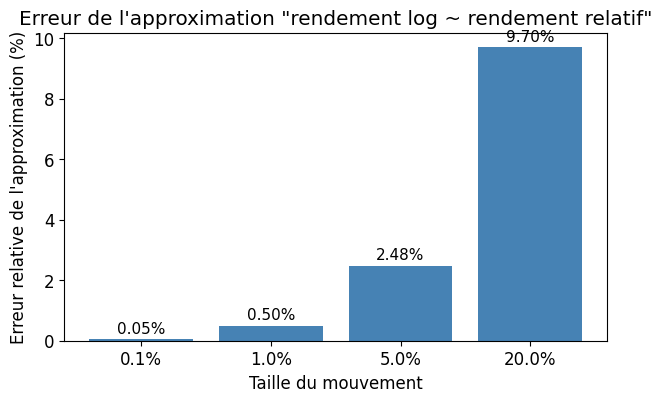

In [ ]:
# L'approximation rendement log ~ rendement relatif est-elle bonne ?
# Ca depend de la taille du mouvement."
# Erreur de l'approximation, en graphique 

mouvements = np.array([0.001, 0.01, 0.05, 0.20])
erreurs = np.abs(np.log(1+mouvements) - mouvements) / np.abs(np.log(1+mouvements)) * 100

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar([f"{m*100:.1f}%" for m in mouvements], erreurs, color="steelblue")
for b, e in zip(bars, erreurs):
    ax.text(b.get_x()+b.get_width()/2, e+0.2, f"{e:.2f}%", ha="center", fontsize=11)
ax.set_title("Erreur de l'approximation \"rendement log ~ rendement relatif\"")
ax.set_xlabel("Taille du mouvement")
ax.set_ylabel("Erreur relative de l'approximation (%)")
plt.show()


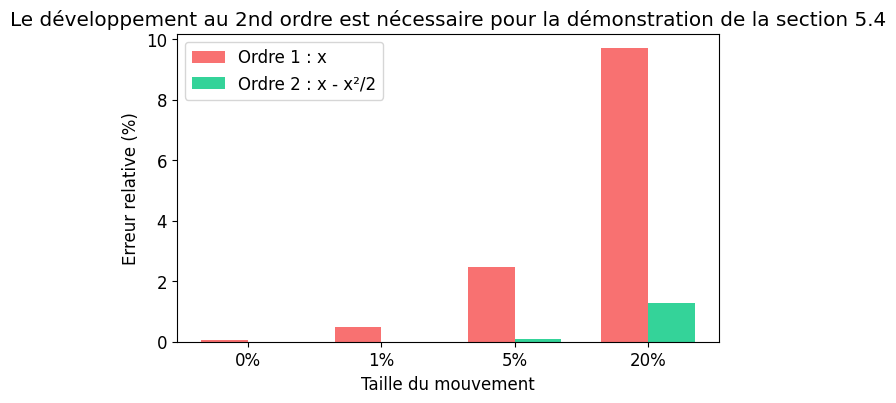

In [ ]:
# "La demonstration de tout a l'heure utilise un developpement au 2eme ordre, pas
# celui du premier ordre qu'on vient de tester. Verifions que le 2eme ordre est bien meilleur."
# Cmparaison des deux ordres d'approximation

fig, ax = plt.subplots(figsize=(7,4))
labels = [f"{m*100:.0f}%" for m in mouvements]
err_ordre1 = erreurs
err_ordre2 = np.abs((mouvements - mouvements**2/2) - np.log(1+mouvements)) / np.abs(np.log(1+mouvements)) * 100

width = 0.35
xpos = np.arange(len(labels))
ax.bar(xpos-width/2, err_ordre1, width, label="Ordre 1 : x", color="#f87171")
ax.bar(xpos+width/2, err_ordre2, width, label="Ordre 2 : x - x²/2", color="#34d399")
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_title("Le développement au 2nd ordre est nécessaire pour la démonstration de la section 5.4")
ax.set_xlabel("Taille du mouvement")
ax.set_ylabel("Erreur relative (%)")
ax.legend()
plt.show()


In [ ]:
# "Deuxieme etape, l'exemple qui montre pourquoi la moyenne ment. On construit une
# petite serie de rendements annuels et on compare trois nombres."
# Le calcul, puis un graphique comparatif 

rendements = np.array([0.12, 0.18, -0.15, 0.22, 0.08])   # exemple pedagogique
capital0 = 100
facteur_croissance = np.prod(1 + rendements)
capital_final = capital0 * facteur_croissance
n = len(rendements)

moyenne_arithmetique = rendements.mean()
rendement_compose = facteur_croissance**(1/n) - 1
variance_rendements = rendements.var(ddof=1)
approx_theorique = moyenne_arithmetique - variance_rendements/2

print(f"100 EUR investis, rendements {list((rendements*100).round(1))}% -> capital final : {capital_final:.2f} EUR")


100 EUR investis, rendements [np.float64(12.0), np.float64(18.0), np.float64(-15.0), np.float64(22.0), np.float64(8.0)]% -> capital final : 148.01 EUR


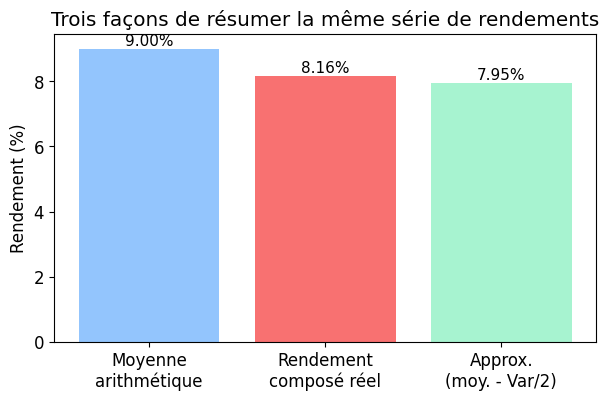

In [5]:
fig, ax = plt.subplots(figsize=(7,4))
labels = ["Moyenne\narithmétique", "Rendement\ncomposé réel", "Approx.\n(moy. - Var/2)"]
valeurs = [moyenne_arithmetique*100, rendement_compose*100, approx_theorique*100]
colors = ["#93c5fd", "#f87171", "#a7f3d0"]
bars = ax.bar(labels, valeurs, color=colors)
for b, v in zip(bars, valeurs):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f"{v:.2f}%", ha="center", fontsize=11)
ax.set_title("Trois façons de résumer la même série de rendements")
ax.set_ylabel("Rendement (%)")
plt.show()


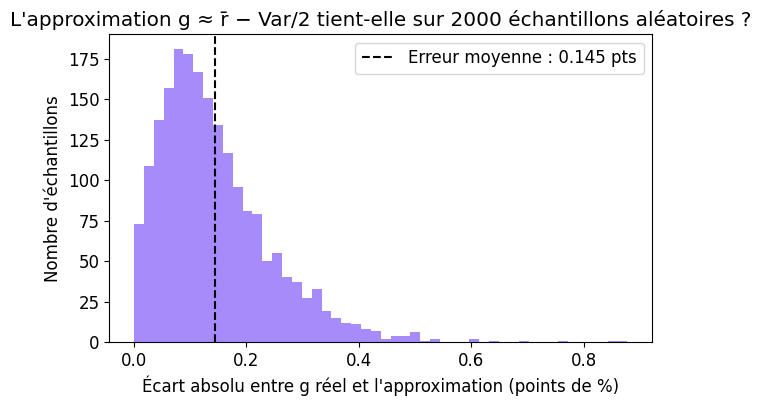

In [ ]:
# "Un seul exemple ne prouve rien -- on verifie que l'approximation tient sur
# beaucoup d'echantillons aleatoires, pas seulement sur les 5 chiffres choisis a la main."
# Robustesse sur 2000 echantillons

erreurs_approx = []
for _ in range(2000):
    r = rng.normal(0.05, 0.15, 10)
    g_reel = np.prod(1+r)**(1/len(r)) - 1
    approx = r.mean() - r.var(ddof=1)/2
    erreurs_approx.append(abs(g_reel - approx)*100)

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(erreurs_approx, bins=50, color="#a78bfa")
ax.axvline(np.mean(erreurs_approx), color="black", linestyle="--",
           label=f"Erreur moyenne : {np.mean(erreurs_approx):.3f} pts")
ax.set_title("L'approximation g ≈ r̄ − Var/2 tient-elle sur 2000 échantillons aléatoires ?")
ax.set_xlabel("Écart absolu entre g réel et l'approximation (points de %)")
ax.set_ylabel("Nombre d'échantillons")
ax.legend()
plt.show()


In [ ]:
# "Sanity check rapide avant d'aller plus loin : vol annuelle simulee a 25%,
# est-ce qu'on la retrouve en ré-estimant a partir de l'echantillon ?"

sigma_annuel_vrai = 0.25
sigma_journalier_vrai = sigma_annuel_vrai / np.sqrt(252)
rets_journaliers = rng.normal(0, sigma_journalier_vrai, 5000)
sigma_annuel_retrouve = rets_journaliers.std(ddof=1) * np.sqrt(252)

print(f"Vol annuelle vraie : {sigma_annuel_vrai*100:.2f}%   ->   vol retrouvée par simulation : {sigma_annuel_retrouve*100:.2f}%")


Vol annuelle vraie : 25.00%   ->   vol retrouvée par simulation : 24.78%


In [ ]:
# "On simule maintenant une vraie trajectoire de prix, avec la methode du cours :
# on choisit mu et sigma, on tire un bruit aleatoire, et on construit le chemin."
# La fonction de simulation (mouvement brownien geometrique)

def simuler_gbm(S0, mu, sigma, T, n_steps, n_paths, seed):
    rng_local = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng_local.standard_normal((n_paths, n_steps))
    rendements_log = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_prix = np.log(S0) + np.cumsum(rendements_log, axis=1)
    prix = np.exp(log_prix)
    return prix, rendements_log


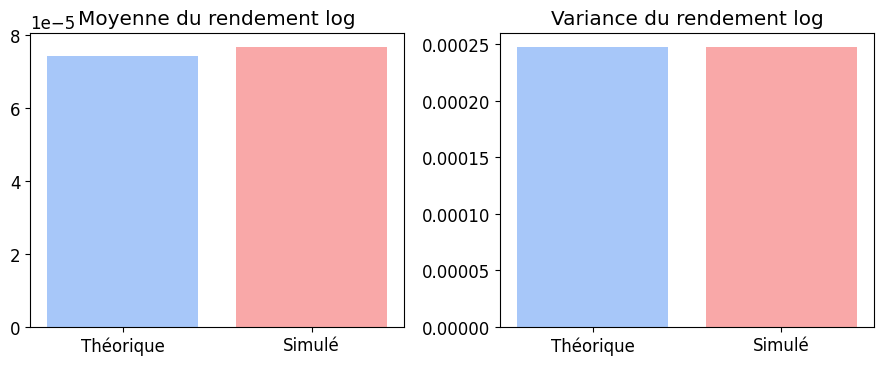

In [ ]:
# verification theorique vs simule, en graphique 

mu, sigma, T, n_steps = 0.05, 0.25, 1.0, 252
_, rendements_log_sim = simuler_gbm(100, mu, sigma, T, n_steps, 100_000, seed=1)
dt = T/n_steps
moyenne_theorique = (mu - 0.5*sigma**2)*dt
variance_theorique = sigma**2*dt
moyenne_simulee = rendements_log_sim.mean()
variance_simulee = rendements_log_sim.var(ddof=1)

fig, axes = plt.subplots(1, 2, figsize=(9,4))
axes[0].bar(["Théorique", "Simulé"], [moyenne_theorique, moyenne_simulee], color=["#a7c7f9","#f9a8a8"])
axes[0].set_title("Moyenne du rendement log")
axes[1].bar(["Théorique", "Simulé"], [variance_theorique, variance_simulee], color=["#a7c7f9","#f9a8a8"])
axes[1].set_title("Variance du rendement log")
plt.tight_layout()
plt.show()


## 7. Visualisation


**Question posée par ce graphique :** à partir de quelle taille de mouvement l'approximation
"rendement log ≈ rendement relatif" cesse-t-elle d'être fiable ?


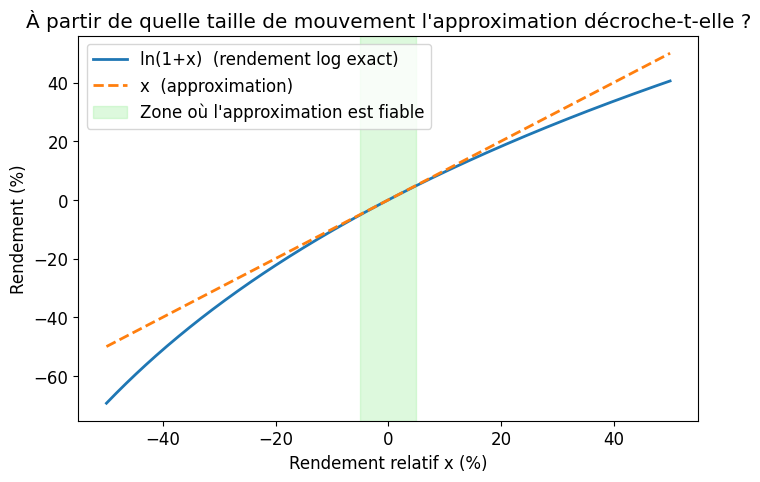

In [10]:
x = np.linspace(-0.5, 0.5, 400)
exact = np.log(1+x)

fig, ax = plt.subplots()
ax.plot(x*100, exact*100, label="ln(1+x)  (rendement log exact)", linewidth=2)
ax.plot(x*100, x*100, label="x  (approximation)", linewidth=2, linestyle="--")
ax.axvspan(-5, 5, color="lightgreen", alpha=0.3, label="Zone où l'approximation est fiable")
ax.set_title("À partir de quelle taille de mouvement l'approximation décroche-t-elle ?")
ax.set_xlabel("Rendement relatif x (%)")
ax.set_ylabel("Rendement (%)")
ax.legend()
plt.show()


**Question posée par ce graphique :** pourquoi un rendement moyen de 0% peut-il quand même
vous faire perdre de l'argent ?


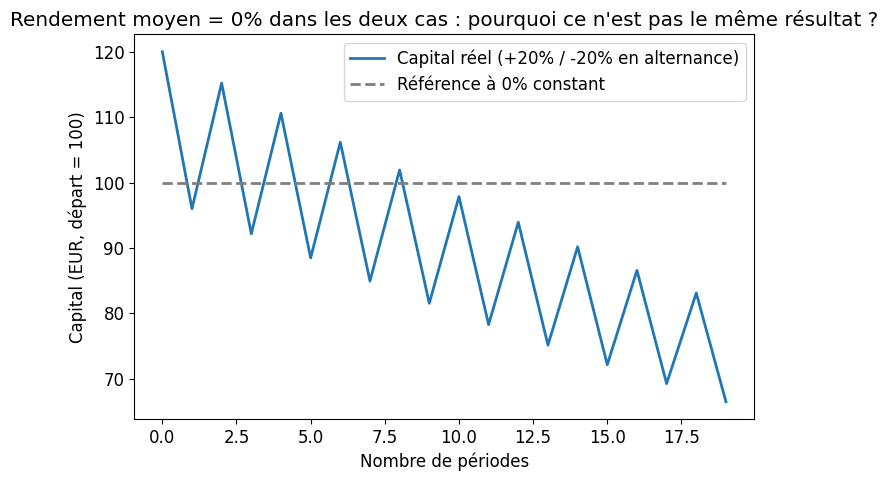

Capital final apres alternance +20%/-20% x10 : 66.48 EUR (moyenne arithmetique des rendements = 0.0%)


In [11]:
# Serie qui alterne +20% / -20% : moyenne arithmetique = 0%
rendements_alternes = np.array([0.20, -0.20]*10)
capital_alterne = 100 * np.cumprod(1 + rendements_alternes)
capital_constant = np.full(len(rendements_alternes), 100.0)  # reference : 0% tout le temps

fig, ax = plt.subplots()
ax.plot(capital_alterne, label="Capital réel (+20% / -20% en alternance)", linewidth=2)
ax.plot(capital_constant, label="Référence à 0% constant", linewidth=2, linestyle="--", color="grey")
ax.set_title("Rendement moyen = 0% dans les deux cas : pourquoi ce n'est pas le même résultat ?")
ax.set_xlabel("Nombre de périodes")
ax.set_ylabel("Capital (EUR, départ = 100)")
ax.legend()
plt.show()

print(f"Capital final apres alternance +20%/-20% x10 : {capital_alterne[-1]:.2f} EUR "
      f"(moyenne arithmetique des rendements = {rendements_alternes.mean()*100:.1f}%)")


## 8. Expériences

**Paramètre qu'on fait varier :** la volatilité (10% vs 40%), à rendement moyen identique — pour
voir concrètement l'effet du terme $-\text{Var}/2$ sur la richesse finale.


In [12]:
# Variante 1 : faible volatilite
mu_exp = 0.08
prix_vol_basse, _ = simuler_gbm(100, mu_exp, 0.10, 5, 252*5, 20_000, seed=10)
capital_final_vol_basse = prix_vol_basse[:, -1]


In [13]:
# Variante 2 : forte volatilite, meme rendement moyen mu
prix_vol_haute, _ = simuler_gbm(100, mu_exp, 0.40, 5, 252*5, 20_000, seed=11)
capital_final_vol_haute = prix_vol_haute[:, -1]

print(f"Meme mu={mu_exp*100:.0f}% dans les deux cas.")
print(f"Capital median apres 5 ans, vol=10% : {np.median(capital_final_vol_basse):.1f} EUR")
print(f"Capital median apres 5 ans, vol=40% : {np.median(capital_final_vol_haute):.1f} EUR")
print(f"Capital moyen apres 5 ans, vol=10%  : {np.mean(capital_final_vol_basse):.1f} EUR")
print(f"Capital moyen apres 5 ans, vol=40%  : {np.mean(capital_final_vol_haute):.1f} EUR")


Meme mu=8% dans les deux cas.
Capital median apres 5 ans, vol=10% : 145.9 EUR
Capital median apres 5 ans, vol=40% : 100.0 EUR
Capital moyen apres 5 ans, vol=10%  : 149.4 EUR
Capital moyen apres 5 ans, vol=40%  : 149.1 EUR


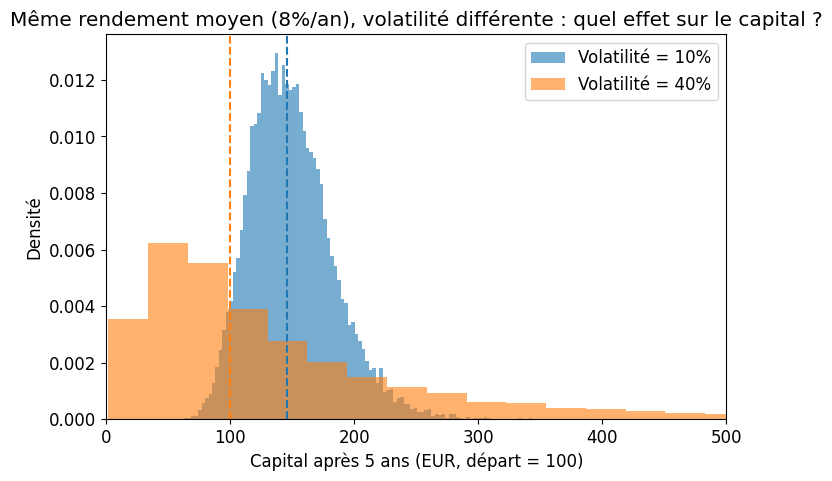

In [ ]:
# distributions comparees

fig, ax = plt.subplots()
ax.hist(capital_final_vol_basse, bins=100, alpha=0.6, label="Volatilité = 10%", density=True)
ax.hist(capital_final_vol_haute, bins=100, alpha=0.6, label="Volatilité = 40%", density=True)
ax.axvline(np.median(capital_final_vol_basse), color="C0", linestyle="--")
ax.axvline(np.median(capital_final_vol_haute), color="C1", linestyle="--")
ax.set_xlim(0, 500)
ax.set_title("Même rendement moyen (8%/an), volatilité différente : quel effet sur le capital ?")
ax.set_xlabel("Capital après 5 ans (EUR, départ = 100)")
ax.set_ylabel("Densité")
ax.legend()
plt.show()


## 9. Résultats

- L'approximation rendement log ≈ rendement relatif est fiable en dessous de quelques %
  d'erreur, mais dérive nettement au-delà de mouvements de 20% (9,7% d'erreur relative).
- Sur l'exemple de 5 rendements annuels, la moyenne arithmétique (9,00%) et le rendement
  réellement composé (8,16%) diffèrent de façon non négligeable — l'approximation théorique
  (moyenne − variance/2 = 7,95%) capture correctement la direction et l'ordre de grandeur de
  cet écart.
- Sanity check validé : la mise à l'échelle en $\sqrt{252}$ retrouve bien la vraie volatilité
  annuelle à partir de rendements simulés.
- **Résultat le plus frappant (section 8)** : avec le même $\mu=8\%$ dans les deux scénarios, le
  capital **moyen** après 5 ans est quasiment identique (149,4€ à vol=10%, 149,1€ à vol=40%) — ce
  qui est exact théoriquement, puisque $\mathbb{E}[S_T]=S_0 e^{\mu T}$ ne dépend pas de $\sigma$.
  Mais le capital **médian** — celui qu'un investisseur "typique" observe réellement — s'effondre
  de 145,9€ à seulement 100,0€ (croissance nulle). La moyenne ne change pas ; ce que vit
  concrètement la plupart des trajectoires, si.


## 10. Interprétation financière

**Pour un investisseur / allocataire :** un rendement moyen annoncé par un fonds ou une stratégie
ne dit pas ce que vous gagnez réellement en restant investi — c'est le rendement composé qui compte,
et il est systématiquement inférieur dès qu'il y a de la volatilité. Deux stratégies avec le même
rendement moyen affiché peuvent avoir des résultats réels très différents si leurs volatilités
diffèrent.

**Pour un trader / risk manager :** cette mécanique est la raison structurelle pour laquelle
réduire la volatilité d'un portefeuille a une valeur en soi, même sans changer son rendement
moyen espéré — ce sera au cœur des vidéos sur le ratio de Sharpe et la gestion du risque.

**Pour un quant :** Hull note explicitement que le terme "expected return" est ambigu — il peut
désigner $\mu$ ou $\mu - \sigma^2/2$ selon le contexte. Cette ambiguïté n'est pas un détail : elle
sera exactement celle qu'on retrouvera en construisant Black-Scholes, où la distinction entre les
deux termes détermine la forme de toute la formule.


## 11. Limites

1. **Rendements i.i.d.** → en réalité, les marchés ont de l'autocorrélation et des "clusters de
   volatilité" (une période volatile a tendance à être suivie d'une autre période volatile) —
   l'hypothèse i.i.d. simplifie cela.
2. **Volatilité constante** → en réalité, la volatilité change dans le temps ; ce sera le sujet du
   palier Volatilité plus loin dans le parcours.
3. **Pas de dividendes ni de frais** → dans un cas réel, ces éléments modifient le rendement
   réellement perçu.
4. **Approximation log ≈ relatif** → comme montré en section 7, cette approximation se dégrade
   pour de grands mouvements — à garder en tête dès qu'on manipule des rendements de plus de
   quelques %.


## 12. Conclusion

**Idée essentielle à retenir :**
> Le rendement moyen ne suffit jamais à décrire une série de rendements : la volatilité elle-même
> mange une partie de la croissance réellement obtenue. Ce n'est pas une anomalie statistique,
> c'est une conséquence directe du fait que les rendements se multiplient dans le temps plutôt que
> de s'additionner.

**Lien vers la vidéo suivante :** on va maintenant voir comment un market maker vit justement de
cette tension entre risque et rendement, en gérant en permanence son inventaire — la prochaine
vidéo du parcours.


## À vous de jouer

Ce notebook est fait pour être modifié, pas seulement lu :

- Changez la volatilité de l'expérience de la section 8 (essayez 5% et 60%) et relancez : à
  partir de quel niveau l'écart entre capital médian et capital moyen devient-il flagrant ?
- Remplacez l'exemple de rendements de la section 6 par vos propres chiffres : est-ce que l'écart
  moyenne/composé est toujours dans le même sens ?
- Essayez un cas extrême : que se passe-t-il si un des rendements est de -80% ? L'approximation
  de la section 5.4 tient-elle encore ?

Le code complet est disponible sur le repo GitHub de la chaîne : `01-rendement-et-volatilite/notebook.ipynb`.
Une question, une erreur trouvée, une suggestion ? Ouvrez une issue sur le repo.


---
## Sources

- Support de cours interne — *Volatilité*, *Mouvement Brownien*
- J. Hull, *Options, Futures and Other Derivatives*, 8e éd., §14.4 et Business Snapshot 14.1
